In [1]:
import matplotlib.pyplot as plt
import numpy as np
import fisher_model as md




### comparaison methode: peut etre un autre fishier  
# fonction cv skearnl 
# comparaison naive/fisher overlap 1D avec mu:cv (peut etre cv sur alpha aussi), overlap vs lambda1 pour diff rho (puis same mais vs lambda2)


In [9]:
def cv_mu(MU, N, rho, lambda1, lambda2, M= 10,  method = "A", plot = False):
    scores = []
    scores_std = []
    for mu in MU:
        score = []
        for _ in range(M): 
            S = md.TwoSpikes(N, lambda1, lambda2, rho, mu = mu)

            if method == "A":
                S.compute_theta1()
                S.compute_methodA()
            score += [S.Loss_eval(method)]
        score = np.array(score)
        scores += [np.mean(score)]
        scores_std += [np.std(score)/np.sqrt(M)]
    mu_opt = MU[np.argmin(scores)]

    if plot:
        plt.errorbar(MU, scores, yerr = scores_std, label = "Loss_EWC")
        plt.axvline(mu_opt, linestyle=":", label="mu_opt")

        
        plt.xlabel("mu")
        plt.ylabel("Loss EWC")
        plt.xscale("log")
        plt.legend()
        plt.title("Cross-validation on mu")
        plt.show()

    return mu_opt, scores, scores_std

0.013888888888888888


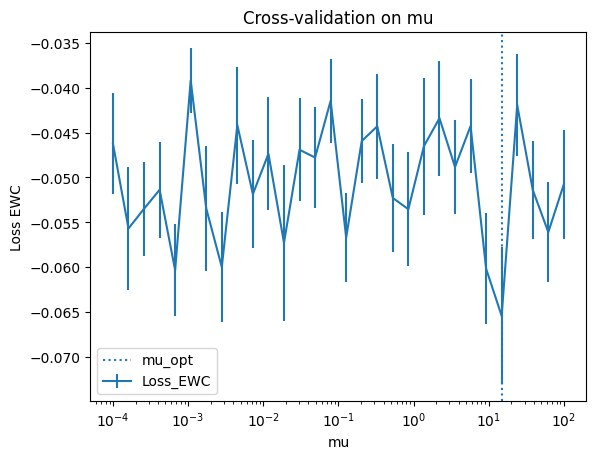

14.873521072935118


In [10]:
MU = np.logspace(-4, 2, 30)
N = 500
rho = 0.3
lambda1 = 7
lambda2 = 1

mu_eq = lambda2/(2*(1-lambda1)**2)
MU = np.linspace(mu_eq - mu_eq, mu_eq + mu_eq, 20)
MU = np.linspace(0, 0.5, 20)
MU = np.logspace(-2, 1, 20)
MU = np.logspace(-4, 2, 30)
print(mu_eq)

# MU = np.linspace(mu_eq - mu_eq, mu_eq + mu_eq, 20)
mu_opt,_, _= cv_mu(MU, N, rho, lambda1, lambda2, M= 20,  method = "A", plot = True)
    
print(mu_opt)

In [2]:

def comparison1D(vary_param, val, N, lambda1, lambda2, rho, mu, M=20, method = ["1", "naive", "A"],optimal_mu = False):

    overlaps1 = {m: {"m1": [], "std1": []} for m in method}
    overlaps2 = {m: {"m2": [], "std2": []} for m in method}
    sumover = {m: {"sum": [], "std": []} for m in method}

    for value in val:
        params = {'N': N, 'lambda1': lambda1, 'lambda2': lambda2, 'rho': rho, 'mu': mu}
        params[vary_param] = value
        m12 = {m: {"m1": [], "m2": []} for m in method}

        if vary_param != "mu":
            mu_eq = params['lambda2']/(2*(1-params['lambda1'])**2)
            MU = np.linspace(mu_eq - mu_eq/10, mu_eq + mu_eq/10, 15)
            if optimal_mu:
                mu_opt,_, _= md.cv_mu(MU, params['N'], params['rho'], params['lambda1'], params['lambda2'], M= 20,  method = "A", plot = True)
            else:
                mu_opt = mu_eq

        # print(f"lambda1: {lambda1:.2f}, mu_opt: {mu_opt:.2f}, mu_eq: {mu_eq:.2f}")
        for _ in range(M):
            S = md.TwoSpikes(params['N'], params['lambda1'], params['lambda2'], params['rho'], params['mu'])
            S.set_mu(mu_opt)
            print(method)
            S.compute_method(method)
            for m in method:
                overlap1, overlap2 = S.overlaps(m)
                m12[m]["m1"].append(overlap1)
                m12[m]["m2"].append(overlap2)
        
        for m in method:
            overlaps1[m]["m1"].append(np.mean(m12[m]["m1"]))
            overlaps1[m]["std1"].append(np.std(m12[m]["m1"])/np.sqrt(M))
            overlaps2[m]["m2"].append(np.mean(m12[m]["m2"]))
            overlaps2[m]["std2"].append(np.std(m12[m]["m2"])/np.sqrt(M))
            sumover[m]["sum"].append((np.mean(m12[m]["m1"])+ np.mean(m12[m]["m2"]))/2)
            sumover[m]["std"].append((np.std(m12[m]["m1"])+ np.std(m12[m]["m2"]))/2)
    
    return overlaps1, overlaps2, sumover

In [3]:
MU = np.logspace(-3, 3, 30)
N = 700
M=10
rho = 0.3
lambda1 = 3
lambda2 = 3
LAM1 = np.linspace(0, 4, 20)
method = ["1", "A", "B"]
RHO = [0, 0.2, 0.4,0.6, 0.8, 1.0]

for rho in RHO:
    print(f"rho: {rho}")
    overlaps1, overlaps2, sumover = comparison1D("lambda1", LAM1, N, lambda1, lambda2, rho,mu = MU M=M, method = method)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Plot overlap 1
    ax = axes[0]

    for m in method:
        ax.errorbar(
            LAM1,
            overlaps1[m]["m1"],
            yerr=overlaps1[m]["std1"],
            label=m,
            capsize=3
        )

    ax.set_xlabel(r'$\lambda_1$')
    ax.set_ylabel('Overlap 1')
    ax.set_title('Overlap avec x1')
    ax.legend()
    ax.grid()


    # Plot overlap 2
    ax = axes[1]

    for m in method:
        ax.errorbar(
            LAM1,
            overlaps2[m]["m2"],
            yerr=overlaps2[m]["std2"],
            label=m,
            capsize=3
        )

    ax.set_xlabel(r'$\lambda_1$')
    ax.set_ylabel('Overlap 2')
    ax.set_title('Overlap avec x2')
    ax.legend()
    ax.grid()

    ax = axes[2]

    for m in method:
        ax.errorbar(
            LAM1,
            sumover[m]["sum"],
            yerr=sumover[m]["std"],
            label=m,
            capsize=3
        )

    ax.set_xlabel(r'$\lambda_1$')
    ax.set_ylabel('Sum of Overlaps')
    ax.set_title('Sum of Overlaps')
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid()


    plt.tight_layout()
    plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1103241303.py, line 13)

rho: 0


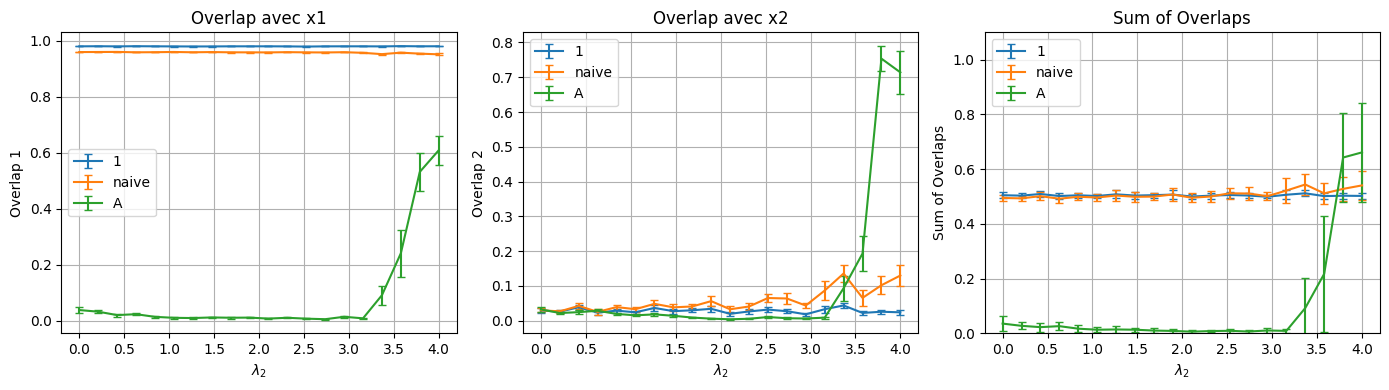

rho: 0.2


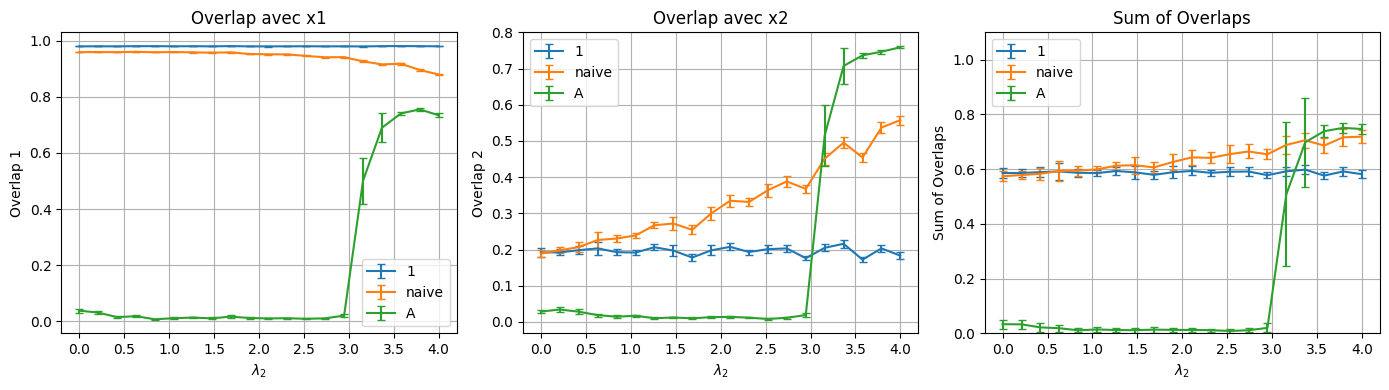

rho: 0.4


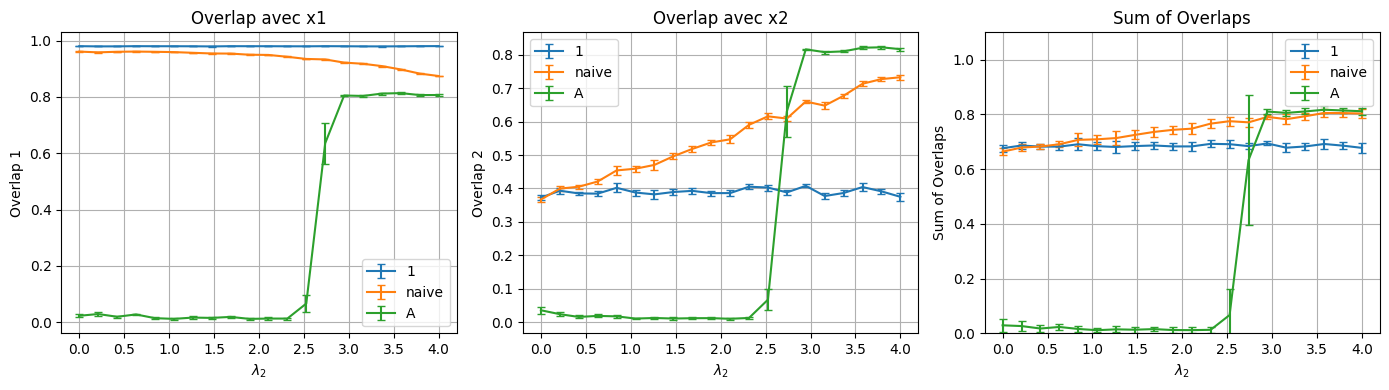

rho: 0.6


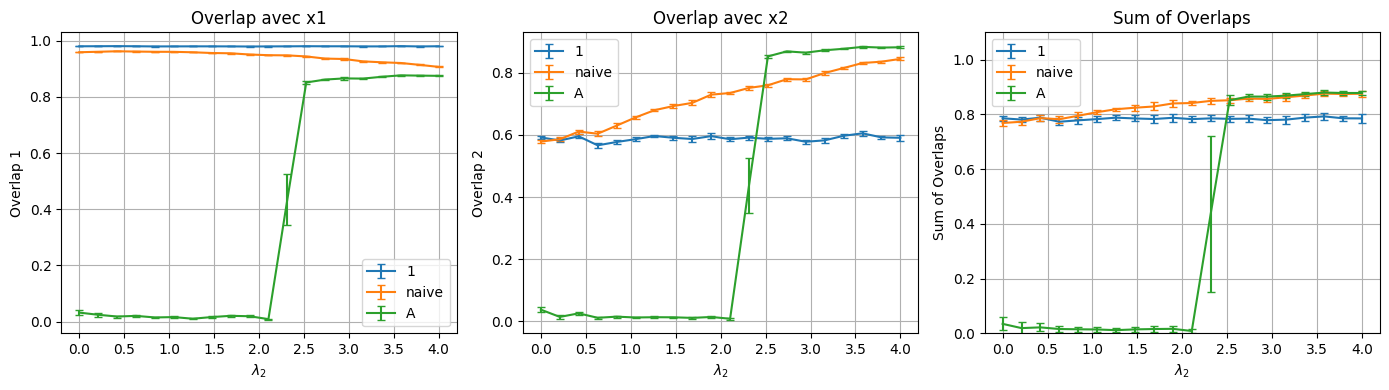

rho: 0.8


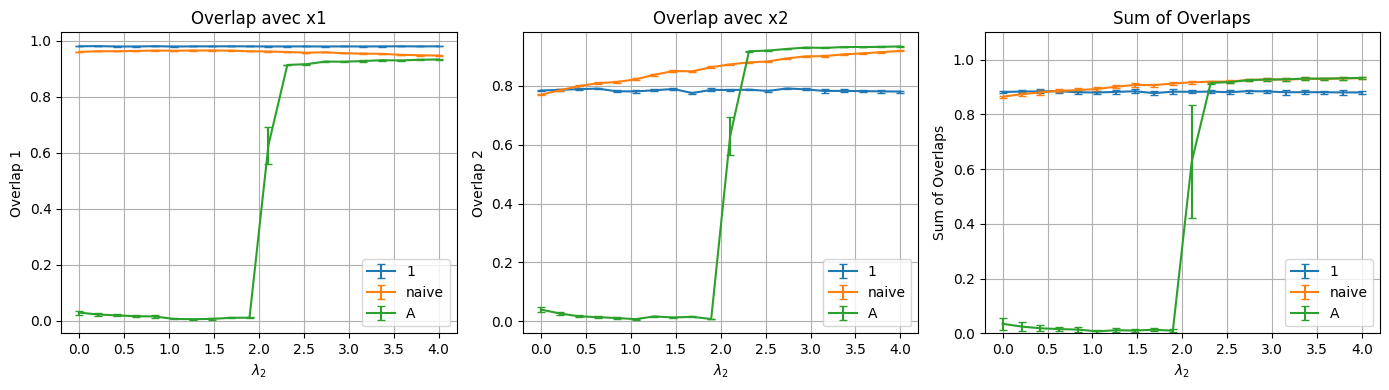

rho: 1.0


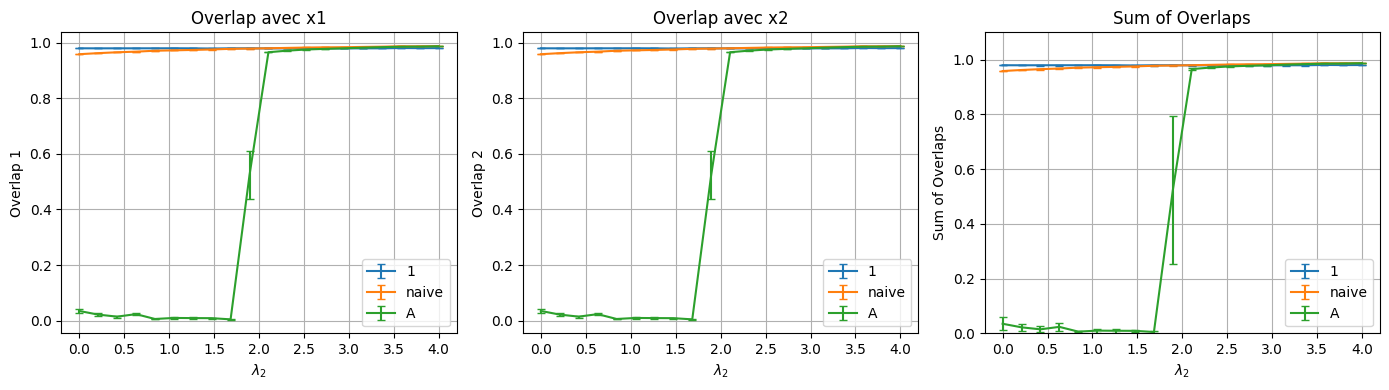

In [6]:
MU = np.logspace(-3, 3, 30)
N = 700
M=10
rho = 0.3
lambda1 = 5
lambda2 = 3
LAM2 = np.linspace(0, 4, 20)
method = ["1", "naive", "A"]
RHO = [0, 0.2, 0.4,0.6, 0.8, 1.0]

for rho in RHO:
    print(f"rho: {rho}")
    overlaps1, overlaps2, sumover = comparison1D("lambda2", LAM2, N, lambda1, lambda2, rho, M=M, method = method)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Plot overlap 1
    ax = axes[0]

    for m in method:
        ax.errorbar(
            LAM1,
            overlaps1[m]["m1"],
            yerr=overlaps1[m]["std1"],
            label=m,
            capsize=3
        )

    ax.set_xlabel(r'$\lambda_2$')
    ax.set_ylabel('Overlap 1')
    ax.set_title('Overlap avec x1')
    ax.legend()
    ax.grid()


    # Plot overlap 2
    ax = axes[1]

    for m in method:
        ax.errorbar(
            LAM2,
            overlaps2[m]["m2"],
            yerr=overlaps2[m]["std2"],
            label=m,
            capsize=3
        )

    ax.set_xlabel(r'$\lambda_2$')
    ax.set_ylabel('Overlap 2')
    ax.set_title('Overlap avec x2')
    ax.legend()
    ax.grid()

    ax = axes[2]

    for m in method:
        ax.errorbar(
            LAM2,
            sumover[m]["sum"],
            yerr=sumover[m]["std"],
            label=m,
            capsize=3
        )

    ax.set_xlabel(r'$\lambda_2$')
    ax.set_ylabel('Sum of Overlaps')
    ax.set_title('Sum of Overlaps')
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid()


    plt.tight_layout()
    plt.show()